In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import colorcet as cc
import warnings
import re
import umap

from norm import cut_norm,interpolate_and_sample

def readsheet(sheetname,excel_file_path):
    data = pd.read_excel(excel_file_path,sheet_name=sheetname)
    columns_to_remove = ['Temp. [°C]']
    data.drop(columns=columns_to_remove, inplace=True)
    return data

c:\Omar\VAE\Code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#SUM ALL THE DATA
excel_file_path = 'WT_in_LB_data_Omar_s1.XLSX'
lsheetnames = ['P0002','P0005','P0008','P0012','P0030']
numbers=[0,1,2,3,4]
excel_file_path2 = 'different_conditions_data_Omar_s2.XLSX'
lsheetnames2 = ['P12_WT','P13_TolC_KO','P16_AcrD_KO','P17_AcrA_KO','P18_AcrB_KO','P24_AcrBD_KO']
numbers2=[0,1,2,3,4,5]
split = [n.split('_') for n in lsheetnames2]
gene= [sublist[1] for sublist in split]         #The strain: WT,AcrA,AcrB,etc...
custom_palette=sns.color_palette(cc.glasbey) 
lsheetnames3 = ['P25_kan_2_50','P27_kan_1_25','P28_kan','P30_kan_2_50']
numbers3=[0,1,2,3]

legend_added = set()  # To keep track of colors for which legend entry is added
time_to_cut=175000
nvalues_to_interpolate=299
sum_data=pd.DataFrame()
sum_data2=pd.DataFrame()
sum_data3=pd.DataFrame()
batches=[]
batch_color_map = {}
color_index = 0
experiments=[]               

# Suppress PerformanceWarning from pandas
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

for sheetname,i in zip(lsheetnames,numbers):
    df = readsheet(sheetname, excel_file_path)
    df=cut_norm(df,time_to_cut)
    df = interpolate_and_sample(df,time_to_cut,nvalues_to_interpolate)
    Time=df['Time [s]'].values
    for column,j in zip(df.columns.values[2:],enumerate(df.columns.values[2:])):
        new_column_name = f'WT_LB_{i}_{j[0]}'
        sum_data[new_column_name]=df[column]
        batch=f'WT_LB_{i}'
        batches.append(batch)
        for batch_ in batches:
            if batch_ not in batch_color_map:
                batch_color_map[batch_] = custom_palette[color_index]
                color_index = (color_index + 1) % len(custom_palette)
        color = batch_color_map[batch]
        # Add legend entry only if the color is not yet added to the legend
        if color not in legend_added:
            legend_added.add(color)  
            experiments.append(batch)


for sheetname2,i in zip(lsheetnames2,numbers2):
    df = readsheet(sheetname2,excel_file_path2)
    df=cut_norm(df,time_to_cut)
    df = interpolate_and_sample(df,time_to_cut,nvalues_to_interpolate)
    split_column_names = [name.split('_') for name in df.columns.values[2:]]
    drugs=[sublist[0] for sublist in split_column_names]
    plate_indexes=[sublist[1] for sublist in split_column_names]
    sum_split=[name.split('_') for name in sum_data.columns]
    joined_sum_split = ['_'.join(parts[:3]) for parts in sum_split]
    for column,drug,plate_index in zip(df.columns.values[2:],drugs,plate_indexes):
        aux=0
        for j in range (len(joined_sum_split)):
            if joined_sum_split[j]==f'{gene[i]}_{drug}_{aux}':
                aux+=1    
        new_column_name = f'{gene[i]}_{drug}_{aux}_{plate_index}'
        sum_data2[new_column_name]=df[column]
        batch=f'{gene[i]}_{drug}_{aux}'
        batches.append(batch)
        for batch_ in batches:
            if batch_ not in batch_color_map:
                batch_color_map[batch_] = custom_palette[color_index]
                color_index = (color_index + 1) % len(custom_palette)
        color = batch_color_map[batch]
        if color not in legend_added:
            legend_added.add(color)  
            experiments.append(batch)

for sheetname3 in lsheetnames3:
    df = readsheet(sheetname3,excel_file_path2)
    df=cut_norm(df,time_to_cut)
    df = interpolate_and_sample(df,time_to_cut,nvalues_to_interpolate)
    split_column_names = [name.split('_') for name in df.columns.values[2:]]
    strain_drugs=['_'.join(parts[:2]) for parts in split_column_names]
    plate_indexes=[sublist[2] for sublist in split_column_names]
    sum_split=[name.split('_') for name in sum_data.columns]
    joined_sum_split = ['_'.join(parts[:3]) for parts in sum_split]
    sum_split2=[name.split('_') for name in sum_data2.columns]
    joined_sum_split2 = ['_'.join(parts2[:3]) for parts2 in sum_split2]
    sum_split3=[name.split('_') for name in sum_data3.columns]
    joined_sum_split3 = ['_'.join(parts[:3]) for parts in sum_split3]
    for column,strain_drug,plate_index in zip(df.columns.values[2:],strain_drugs,plate_indexes):
        aux=0
        for j in range (len(joined_sum_split)):
            if joined_sum_split[j]==f'{strain_drug}_{aux}':
                aux+=1   
        for k in range (len(joined_sum_split2)):
            if joined_sum_split2[k]==f'{strain_drug}_{aux}':
                aux+=1 
        for l in range (len(joined_sum_split3)):
            if joined_sum_split3[l]==f'{strain_drug}_{aux}':
                aux+=1       
        new_column_name = f'{strain_drug}_{aux}_{plate_index}'
        sum_data3[new_column_name]=df[column]
        batch=f'{strain_drug}_{aux}'
        batches.append(batch)
        for batch in batches:
            if batch not in batch_color_map:
                batch_color_map[batch] = custom_palette[color_index]
                color_index = (color_index + 1) % len(custom_palette)
        color = batch_color_map[batch]
        if color not in legend_added:
            legend_added.add(color)  
            experiments.append(batch)

total_data = pd.concat([sum_data, sum_data2,sum_data3], axis=1)

In [31]:
#Reorder the data by drugs/strains
train_data=pd.DataFrame()
test_data=pd.DataFrame()
batches_test=[]
batches_train=[]
np.random.seed(4)

columns=total_data.columns[:]
num_list = list(range(len(batches)))

experiments2=[]
split_experiments=[name.split('_') for name in experiments]
exp=1       #[1] for drugs, [0] for strain
experimentos=[sublist[exp] for sublist in split_experiments]
batches2=[]
parts=[name.split('_') for name in batches]
batches2=[sublist[exp] for sublist in parts]      
print(len(batches2))

for experimento in experimentos:
    if experimento not in experiments2:
        experiments2.append(experimento)

print(len(experiments2),experiments2)

#Select the test_data and the train_data, 15% splitting
for experiment in experiments2:
    columns_to_select=[]
    for batch,i in zip(batches2,num_list):
        if batch==experiment:
            columns_to_select.append(columns[i])
    #print(experiment,len(columns_to_select))              
    num_columns_to_select = int(len(columns_to_select) * 0.15)        
    test_columns = np.random.choice(columns_to_select, num_columns_to_select,replace=False)
    batches_test.extend([experiment] * len(test_columns))
    test_columns_data = total_data[test_columns]
    train_columns = [col for col in columns_to_select if col not in test_columns]
    train_columns_data = total_data[train_columns]
    print(len(test_columns),len(columns_to_select),num_columns_to_select,len(train_columns)+len(test_columns))
    test_data = pd.concat([test_data, test_columns_data], axis=1)
    train_data = pd.concat([train_data, train_columns_data], axis=1)
    batches_train.extend([experiment] * len(train_columns))

print(test_data.shape,train_data.shape)
print('The number of total growth curves is:',len(batches_test),len(batches_train))         

train_data_T=train_data.T
test_data_T=test_data.T
X_train3=train_data_T.values
X_test3=test_data_T.values
X_train_tensor3 = torch.FloatTensor(X_train3)
X_test_tensor3 = torch.FloatTensor(X_test3)

custom_palette=sns.color_palette(cc.glasbey,len(batches_test)) 

816
16 ['LB', 'K1.25', 'K2.50', 'K3.75', 'M0.25', 'M0.50', 'M1.00', 'K1.25&M0.25', 'K1.25&M0.50', 'K1.25&M1.00', 'K2.50&M0.25', 'K2.50&M0.50', 'K2.50&M1.00', 'K3.75&M0.25', 'K3.75&M0.50', 'K3.75&M1.00']
29 195 29 195
14 98 14 98
22 149 22 149
6 44 6 44
4 32 4 32
4 32 4 32
4 32 4 32
3 26 3 26
3 26 3 26
3 26 3 26
3 26 3 26
3 26 3 26
3 26 3 26
3 26 3 26
3 26 3 26
3 26 3 26
(100, 110) (100, 706)
The number of total growth curves is: 110 706


(110, 100) (706, 100)
Iniciando la reducción de dimensionalidad con UMAP...


c:\Omar\VAE\Code\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


¡UMAP completado!


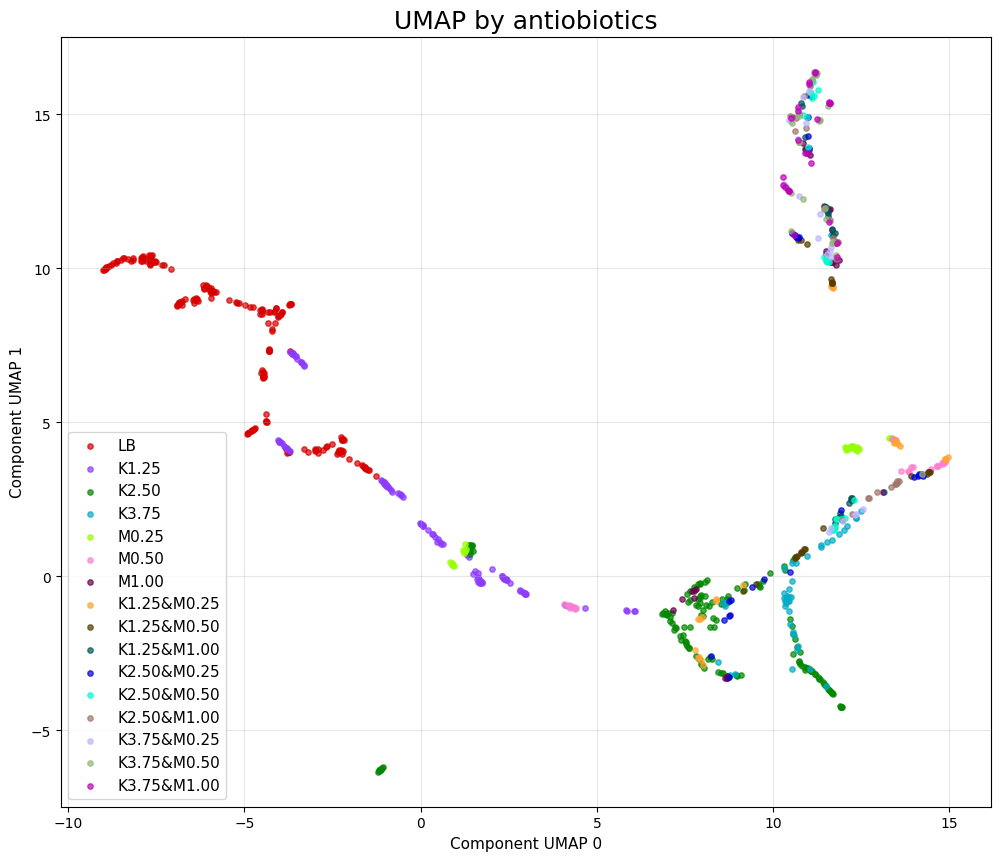

In [32]:
print(X_test3.shape,X_train3.shape)
total_dataset = pd.DataFrame(np.concatenate((X_test3, X_train3), axis=0))
dataset_batches=np.concatenate((batches_test, batches_train))

# Crear la paleta de colores:
custom_palette=sns.color_palette(cc.glasbey,len(experiments2)) 
palette_dict = {batch: color for batch, color in zip(experiments2, custom_palette)}

# 2. EJECUCIÓN UMAP
reducer = umap.UMAP(
    n_neighbors=15, 
    min_dist=0.1, 
    n_components=2, 
    random_state=42 
)

print("Iniciando la reducción de dimensionalidad con UMAP...")
embedding_2D = reducer.fit_transform(total_dataset.values) 
print("¡UMAP completado!")

# 3. VISUALIZACIÓN GARANTIZANDO LEYENDA ÚNICA
plt.figure(figsize=(12, 10))

# Iteramos sobre los valores ÚNICOS para dibujar los puntos
# Esto garantiza que el 'label' para la leyenda se use solo una vez por tipo de lote.
for batch_name in experiments2:
    # 1. Filtra los índices que pertenecen al lote actual
    indices = dataset_batches == batch_name
    
    # 2. Dibuja solo los puntos de ese lote
    plt.scatter(
        embedding_2D[indices, 0], 
        embedding_2D[indices, 1],
        color=palette_dict[batch_name], # Color asignado de la paleta
        label=f'{batch_name}',    # Etiqueta ÚNICA para la leyenda
        s=15,
        alpha=0.7 
    )

plt.title('UMAP by antiobiotics', fontsize=18)
plt.xlabel('Component UMAP 0',fontsize=11)
plt.ylabel('Component UMAP 1',fontsize=11)
plt.legend(loc='best',fontsize=11) # Muestra la leyenda basada en los 'labels' únicos
plt.grid(True, alpha=0.3)
plt.show()

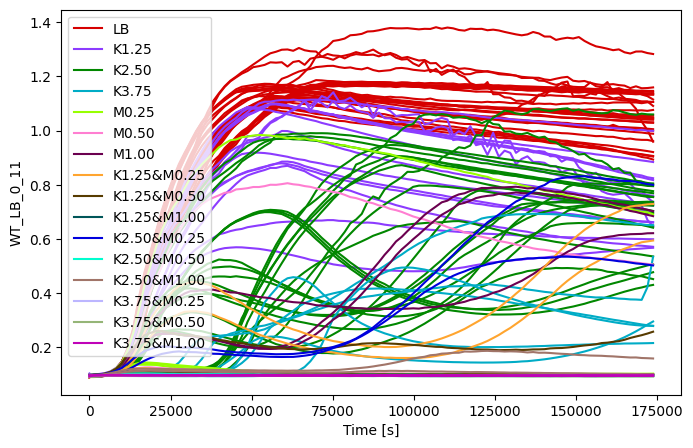

In [20]:
fig, ax = plt.subplots(1,1,figsize=[8,5])
custom_palette=sns.color_palette(cc.glasbey,len(experiments2)) 

total_data['Time [s]'] = Time
test_data['Time [s]'] = Time
train_data['Time [s]'] = Time
legend_added = set()  
batch_color_map = {}
color_index = 0
for batch in batches2:
    if batch not in batch_color_map:
        batch_color_map[batch] = custom_palette[color_index]
        color_index = (color_index + 1) % len(custom_palette)

for column,batch in zip(test_data.columns.values[:len(batches_test)],batches_test):
    color = batch_color_map[batch]
    if color not in legend_added:
        sns.lineplot(data=test_data, x=test_data['Time [s]'], y=column,ax=ax,color=color,label=batch)
        legend_added.add(color)  # Add the color to the set to indicate the legend entry is added
    else:
        sns.lineplot(data=test_data, x=test_data['Time [s]'], y=column,ax=ax,color=color)

# for column,batch in zip(total_data.columns.values[:len(batches2)],batches2):
#     color = batch_color_map[batch]
#     if(batch=='K1.25'):
#         if color not in legend_added:
#             sns.lineplot(data=total_data, x=total_data['Time [s]'], y=column,ax=ax,color=color,label=batch)
#             legend_added.add(color)  # Add the color to the set to indicate the legend entry is added
#         else:
#             sns.lineplot(data=total_data, x=total_data['Time [s]'], y=column,ax=ax,color=color)

ax.legend()

In [7]:
class robust_VAE(nn.Module):
    def __init__(self, input_dim, latent_dim, num_hidden_layers, hidden_dims):
        super(robust_VAE, self).__init__()
        
        # Construct the encoder
        encoder_layers = []
        prev_dim = input_dim
        for i in range(num_hidden_layers):
            encoder_layers.append(nn.Linear(prev_dim, hidden_dims[i]))
            encoder_layers.append(nn.Sigmoid())
            prev_dim = hidden_dims[i]
        
        self.encoder = nn.Sequential(*encoder_layers)
        
        # Mean and log variance layers
        self.mean_layer = nn.Linear(hidden_dims[-1], latent_dim)
        self.logvar_layer = nn.Linear(hidden_dims[-1], latent_dim)
        
        # Construct the decoder
        decoder_layers = []
        prev_dim = latent_dim
        for i in reversed(range(num_hidden_layers)):
            decoder_layers.append(nn.Linear(prev_dim, hidden_dims[i]))
            decoder_layers.append(nn.Sigmoid())
            prev_dim = hidden_dims[i]
        
        decoder_layers.append(nn.Linear(hidden_dims[0], input_dim))
        
        self.decoder = nn.Sequential(*decoder_layers)
        
    def encode(self, x):
        x = self.encoder(x)
        mean, logvar = self.mean_layer(x), self.logvar_layer(x)
        return mean, logvar

    def reparameterization(self, mean, logvar):
        epsilon = torch.randn_like(logvar)   
        z = mean + torch.exp(logvar * 0.5) * epsilon   
        return z

    def decode(self, x):
        return self.decoder(x)

    def forward(self, x):
        mean, logvar = self.encode(x)
        z = self.reparameterization(mean, logvar)
        x_hat = self.decode(z)
        return x_hat, mean, logvar

def loss_function(x, x_hat, mean, log_var,alpha):
    reproduction_loss =nn.MSELoss()(x,x_hat)
    KLD = (- 0.5 * torch.sum(1+ log_var - mean.pow(2) - log_var.exp()))/(x.shape[0])
    aux=reproduction_loss.detach().numpy()
    return reproduction_loss + alpha*KLD,aux

In [8]:
class robust_VAE2(nn.Module):
    def __init__(self, input_dim, latent_dim, num_hidden_layers):
        super(robust_VAE2, self).__init__()
        
        # Calculate hidden dimensions
        hidden_dims = []
        step = (input_dim - latent_dim) // (num_hidden_layers + 1)  # Calculate the difference between input_dim and latent_dim
        hidden_dims.append(input_dim - step)

        for i in range(1,num_hidden_layers):
            next_dim = hidden_dims[-1] - step
            hidden_dims.append(next_dim)

        # Construct the encoder
        encoder_layers = []
        prev_dim = input_dim
        for i in range(num_hidden_layers):
            encoder_layers.append(nn.Linear(prev_dim, hidden_dims[i]))
            encoder_layers.append(nn.Sigmoid())
            prev_dim = hidden_dims[i]
        
        self.encoder = nn.Sequential(*encoder_layers)
        
        # Mean and log variance layers
        self.mean_layer = nn.Linear(hidden_dims[-1], latent_dim)
        self.logvar_layer = nn.Linear(hidden_dims[-1], latent_dim)
        
        # Construct the decoder
        decoder_layers = []
        prev_dim = latent_dim
        for i in reversed(range(num_hidden_layers)):
            decoder_layers.append(nn.Linear(prev_dim, hidden_dims[i]))
            decoder_layers.append(nn.Sigmoid())
            prev_dim = hidden_dims[i]
        
        decoder_layers.append(nn.Linear(hidden_dims[0], input_dim))
        
        self.decoder = nn.Sequential(*decoder_layers)
        
    def encode(self, x):
        x = self.encoder(x)
        mean, logvar = self.mean_layer(x), self.logvar_layer(x)
        return mean, logvar

    def reparameterization(self, mean, logvar):
        epsilon = torch.randn_like(logvar)
        z = mean + torch.exp(logvar * 0.5) * epsilon
        return z

    def decode(self, x):
        return self.decoder(x)

    def forward(self, x):
        mean, logvar = self.encode(x)
        z = self.reparameterization(mean, logvar)
        x_hat = self.decode(z)
        return x_hat, mean, logvar

In [9]:
torch.manual_seed(42)
trained_models = []

input_dim = X_train3.shape[1]  # Number of input features
latent_dim = 2  # Desired number of output dimensions
num_hidden_layers=2
hidden_layers=[48,16]      #From bigger to smaller
model = robust_VAE(input_dim, latent_dim,num_hidden_layers,hidden_layers)
alpha=5E-5  #5E-5
str_alpha="{:.0E}".format(alpha)


# Optimizer
optimizer = optim.Adam(model.parameters(), lr=1E-3)     #Optimizer algorithm, lr: learning rate 1E-3

# Training the autoencoder
num_epochs = 20000          #Number of 'jumps' 15000
train_losses = []
test_losses = []
mse_test=0
for epoch in range(num_epochs):
   # Training phase
   x_hat, mean, log_var = model(X_train_tensor3)            # Forward pass
   train_loss,_ = loss_function(X_train_tensor3, x_hat, mean, log_var,alpha)

   # Backward pass and optimization, in fact this is the training of the parameters of the model
   optimizer.zero_grad()         #In this way the gradient is not cumulative
   train_loss.backward()             #The gradients (derivatives) of the parameters to optimize (points of the growth) 
   optimizer.step()              #Actualize the optimizer(do the step of the optimizer), in the case of the Adam it multiplies the new vector by the lr

   train_losses.append(train_loss.item())  # Append train loss
   
   with torch.no_grad():  # Disable gradient calculation for the test evaluation
      x_hat, mean, log_var = model(X_test_tensor3)            # Forward pass
      test_loss,mse_test = loss_function(X_test_tensor3, x_hat, mean, log_var,alpha)
   print(test_loss.detach().numpy(),mse_test)
   test_losses.append(test_loss.item())  # Append test loss
trained_models.append(model)
#torch.save(model.state_dict(), 'saved_models/VAE_n1000_alpha{str_alpha[0]}E{str_alpha[4]}lr5E4_v3.pth')
print(f'Epoch [{epoch + 1}/{num_epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')

0.44397888 0.4439786
0.42055196 0.42055157
0.3979705 0.39796993
0.37667984 0.37667906
0.35664842 0.35664737
0.33853883 0.33853748
0.3212744 0.3212727
0.30519286 0.30519074
0.29074752 0.290745
0.2769598 0.2769568
0.26395628 0.26395276
0.2525239 0.25251988
0.24162686 0.24162227
0.23156753 0.23156236
0.22297879 0.22297302
0.21449904 0.21449265
0.20708854 0.20708153
0.2003571 0.20034942
0.19432402 0.19431569
0.18882532 0.18881634
0.18387783 0.18386818
0.17950425 0.17949393
0.17565122 0.17564024
0.17230733 0.17229569
0.16941471 0.16940242
0.16654035 0.1665274
0.16444503 0.16443144
0.16259351 0.1625793
0.16104732 0.1610325
0.15969026 0.15967482
0.15843095 0.15841495
0.15733306 0.15731649
0.15665726 0.15664014
0.15606236 0.15604472
0.15541482 0.15539667
0.15470462 0.15468599
0.15451999 0.1545009
0.15397926 0.15395972
0.15369904 0.15367909
0.15318613 0.15316579
0.15322256 0.15320186
0.15303898 0.15301794
0.15276201 0.15274064
0.15257555 0.15255389
0.15231825 0.15229632
0.15251979 0.1524976
0.1

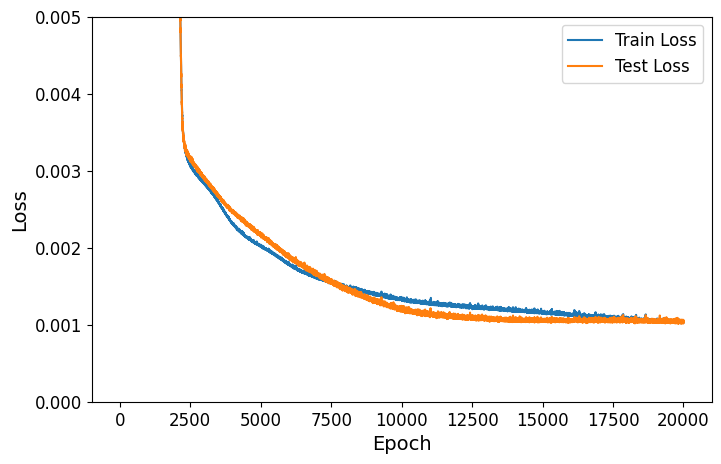

In [10]:
fig, ax = plt.subplots(1,1,figsize=[8,5])
#plt.title('Train and Test Loss over Epochs')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
epochs = range(1, num_epochs + 1)

sns.lineplot(x=epochs, y=train_losses, label='Train Loss',ax=ax)
sns.lineplot(x=epochs, y=test_losses, label='Test Loss',ax=ax)
ax.set_ylim(0, 0.005)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend(fontsize=12)

120 (100, 121)
1 31 ['WT']
1 23 ['WT', 'TolC']
1 16 ['WT', 'TolC', 'AcrD']
1 16 ['WT', 'TolC', 'AcrD', 'AcrA']
1 16 ['WT', 'TolC', 'AcrD', 'AcrA', 'AcrB']
1 8 ['WT', 'TolC', 'AcrD', 'AcrA', 'AcrB', 'AcrBD']
1 5 ['WT', 'TolC', 'AcrD', 'AcrA', 'AcrB', 'AcrBD', 'AcrE']
1 5 ['WT', 'TolC', 'AcrD', 'AcrA', 'AcrB', 'AcrBD', 'AcrE', 'AcrF']


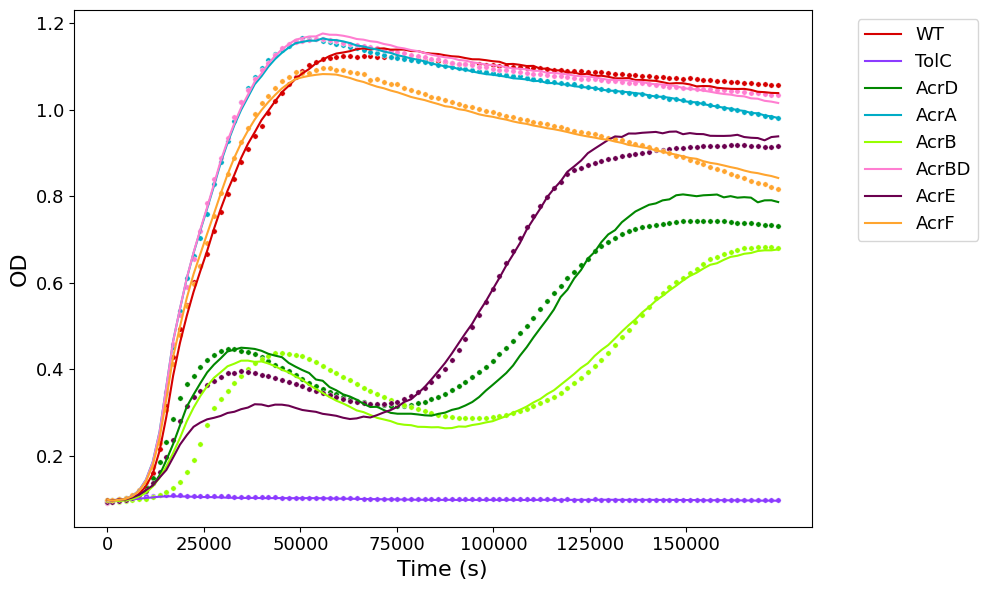

In [11]:
#Plotting the decoded vectors
fig, ax = plt.subplots(1,1,figsize=[10,6])
custom_palette=sns.color_palette(cc.glasbey,len(experiments2))

model=trained_models[0]
print(len(batches_test),test_data.shape)        
columns2=test_data.columns[:len(batches_test)]
num_list2 = list(range(len(batches_test)))
test_data2=pd.DataFrame()
batches_test2=[]
np.random.seed(4)

#take only one curve from each experiment to not overcharge the plot
for experiment in experiments2:
    columns_to_select=[]
    for batch,i in zip(batches_test,num_list2):
        if batch==experiment:
            columns_to_select.append(columns2[i])    
    test_columns = np.random.choice(columns_to_select,1,replace=False)
    batches_test2.append(experiment)
    test_columns_data = total_data[test_columns]
    print(len(test_columns),len(columns_to_select),batches_test2)
    test_data2 = pd.concat([test_data2, test_columns_data], axis=1)

#transform the subset test in a tensor, encode it and decode it
test_data2_T=test_data2.T
X_test4=test_data2_T.values
X_test_tensor4 = torch.FloatTensor(X_test4)

test_mean,test_logvar = model.encode(X_test_tensor4)
test_mean = test_mean.detach().numpy()
test_logvar = test_logvar.detach().numpy()

decoded_test2 = model.decode(torch.FloatTensor(test_mean)).detach().numpy()
decoded_test2_df=pd.DataFrame(decoded_test2).T

decoded_test2_df['Time [s]'] = Time
test_data2['Time [s]'] = Time
 

for column,column2,color,batch in zip(decoded_test2_df.columns.values[:len(batches_test2)],test_data2.columns.values[:len(batches_test2)], custom_palette,batches_test2):
    sns.lineplot(data=decoded_test2_df, x='Time [s]', y=column, ax=ax, color=color, label=batch)
    sns.scatterplot(data=test_data2, x='Time [s]', y=column2, ax=ax, color=color,s=15)

plt.xlabel('Time (s)', fontsize=16)
plt.ylabel('OD', fontsize=16)
ax.set_xticks(range(0, 175000, 25000))
ax.tick_params(axis='both', which='major', labelsize=13)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', prop={'size': 13})
plt.tight_layout()  # Adjust layout to make room for the legend
plt.show()



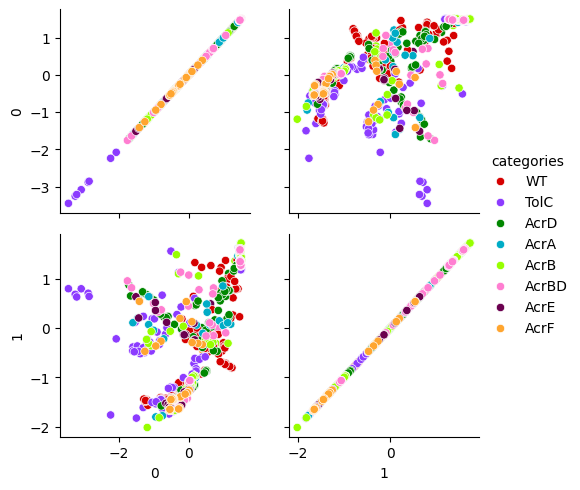

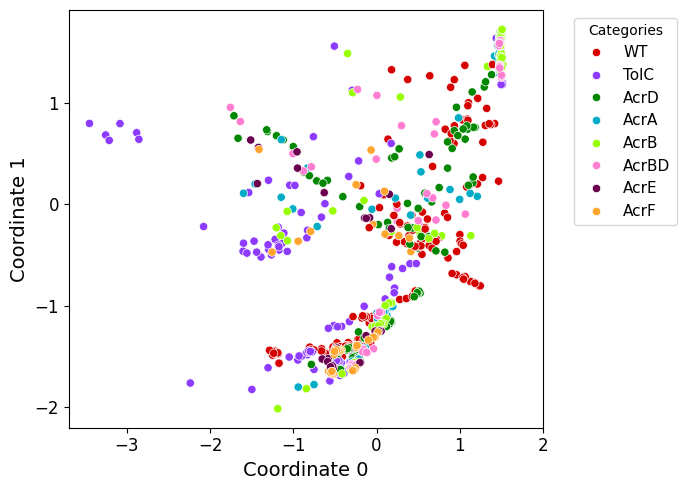

In [12]:
# Encoding the data using the trained autoencoder
test_mean,test_logvar = model.encode(X_test_tensor3)
train_mean,train_logvar = model.encode(X_train_tensor3)
test_mean = test_mean.detach().numpy()
test_logvar = test_logvar.detach().numpy()
train_mean = train_mean.detach().numpy()
train_logvar = train_logvar.detach().numpy()

total_mean_df = pd.DataFrame(np.concatenate((test_mean, train_mean), axis=0))
dataset_batches=np.concatenate((batches_test, batches_train))
total_mean_df['categories']=dataset_batches

custom_palette=sns.color_palette(cc.glasbey,len(experiments2)) 
g = sns.PairGrid(total_mean_df,hue='categories',palette=custom_palette)
g.map(sns.scatterplot)
g.add_legend()

x_col = g.x_vars[0]  # The x variable for the subplot at (1, 0)
y_col = g.y_vars[1]  # The y variable for the subplot at (1, 0)
data_subset = total_mean_df[[x_col, y_col, 'categories']]

# Define points
p1 = (-1.6, -1.5)
p2 = (-1.2, 0)
p3 = (-2.0, 0.4)

# Plot the extracted data in a new figure
fig, ax = plt.subplots(1,1,figsize=[7,5])
sns.scatterplot(data=data_subset, x=x_col, y=y_col, hue='categories', palette=custom_palette)

# Add the dashed line
x_start, x_end = -1.6, 1.40
y_start, y_end = -1.1, 0.0
# plt.plot([x_start, x_end], [y_start, y_end], linestyle='--', color='black')

# Function to add multiple arrows along a line
def add_arrows(x_start, x_end, y_start, y_end, num_arrows=5, arrow_length=0.1):
    arrowprops = dict(facecolor='black', edgecolor='black', arrowstyle='-|>', lw=1)
    for i in np.linspace(0, 1, num_arrows, endpoint=False)[1:]:
        x = x_start + i * (x_end - x_start)
        y = y_start + i * (y_end - y_start)
        dx = (x_end - x_start) * arrow_length / np.hypot(x_end - x_start, y_end - y_start)
        dy = (y_end - y_start) * arrow_length / np.hypot(x_end - x_start, y_end - y_start)
        ax.annotate('', xy=(x + dx, y + dy), xytext=(x, y), arrowprops=arrowprops)

# # Add arrows along the dashed line
# add_arrows(x_start, x_end, y_start, y_end, num_arrows=7, arrow_length=0.15)
# # Add circles at the specified points
# circle1 = plt.Circle(p1, 0.1, color='black', fill=False, linewidth=2, zorder=5)  # Adjust radius as needed
# circle2 = plt.Circle(p2, 0.1, color='black', fill=False, linewidth=2, zorder=5)
# circle3 = plt.Circle(p3, 0.1, color='black', fill=False, linewidth=2, zorder=5)
# ax.add_artist(circle1)
# ax.add_artist(circle2)
# ax.add_artist(circle3)
# plt.text(p1[0]-0.11, p1[1], 'p1', fontsize=12, color='black', ha='right')
# plt.text(p2[0]-0.11, p2[1], 'p2', fontsize=12, color='black', ha='right')
# plt.text(p3[0], p3[1]+0.15, 'p3', fontsize=12, color='black', ha='right')
# plt.text(x_start-0.02, y_start, '0', fontsize=12, color='black', ha='right')
# plt.text(x_end+0.1, y_end, '9', fontsize=12, color='black', ha='right')
# # Customize the plot

plt.xlabel('Coordinate 0', fontsize=14)
plt.ylabel('Coordinate 1', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xticks(np.arange(-3.0, 2.1, 1.)) 
ax.set_yticks(np.arange(-2.0, 1.6, 1.))
# Place the legend outside the plot
plt.legend(title='Categories', bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=11)
plt.tight_layout()  # Adjust layout to make room for the legend
plt.show()



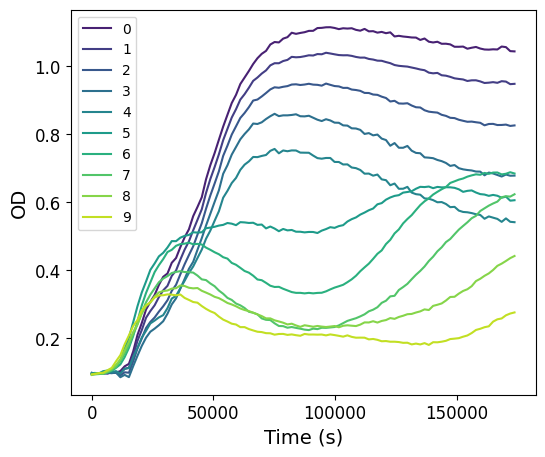

In [13]:
#Now lets see how is the form of the whole latent space to check the completeness and continuity
min_value=[-1.6, -1.1]
max_value=[1.40, 0.0]
whole_latent_space=np.linspace(min_value,max_value,num=10)     #curves from the latent space

#Decoding the data using the trained autoencoder 
whole_latent_space_df= pd.DataFrame(model.decoder(torch.FloatTensor(whole_latent_space)).detach().numpy())

#Transpose it in order to plot 
whole_latent_space_df=whole_latent_space_df.T
whole_latent_space_df['Time [s]'] = Time

fig, ax = plt.subplots(1,1,figsize=[6,5])

#Plot the decoded vectors
custom_palette2=sns.color_palette('viridis',10)
for column, color in zip(whole_latent_space_df.columns.values[:len(whole_latent_space)], custom_palette2[:len(whole_latent_space)]):
    sns.lineplot(data=whole_latent_space_df, x='Time [s]', y=column, ax=ax, color=color, label=whole_latent_space_df.columns.values[column])

plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('OD', fontsize=14)
ax.set_xticks(range(0, 175000, 50000))
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend()

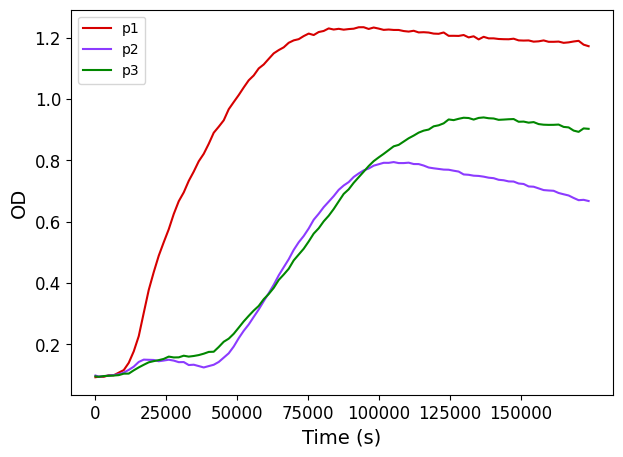

In [14]:
#Now lets see how is the form of the whole latent space to check the completeness and continuity
p1=[-1.6,-1.5]    #'LB'
p2=[-1.2, 0]    #'K2.50' 
p3=[-2.0, 0.4]     #'K2.50'  
specific_points=[p1,p2,p3]     

#Decoding the data using the trained autoencoder 
decoded_points= pd.DataFrame(model.decode(torch.FloatTensor(specific_points)).detach().numpy())

#Transpose it in order to plot 
decoded_points=decoded_points.T
new_column_names=['p1','p2','p3']
decoded_points.columns=new_column_names
decoded_points['Time [s]'] = Time

fig, ax = plt.subplots(1,1,figsize=[7,5])

#Plot the decoded vectors
palette=sns.color_palette(cc.glasbey,len(experiments2))
for column, color in zip(decoded_points.columns.values[:len(specific_points)], palette):
    sns.lineplot(data=decoded_points, x='Time [s]', y=column, ax=ax, color=color, label=column)

plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('OD', fontsize=14)
ax.set_xticks(range(0, 175000, 25000))
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend()